**Life Cycle of Machine Learning Project**



*   Understanding The problem statement
*   Data Collection

*   Data Checks to perform

*   Exploratory Data Analysis


*   Data Pre-Processing
*   Model Training

*   Choose best model










1) Problem Statement

The objective of this dataset is to analyze how factors such as age, gender, BMI, smoking habits, and region influence medical insurance charges.

Using these attributes, the goal is to build a predictive model that accurately estimates insurance costs for individuals.

2) Data Collection



*   Dataset Source -
https://www.kaggle.com/datasets/mirichoi0218/insurance
*   The dataset consist of 7 columns and 1338 rows.



2.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

**Import the CSV Data as Pandas DataFrame**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)
import os
file_name = os.listdir(path)[0]
file_name

df=pd.read_csv("{}/{}".format(path, file_name))
df.head()

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Show Top 5 records

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Shape of the dataset**

In [4]:
df.shape

(1338, 7)

2.2 Dataset information

1) age

Type: Numerical (Integer)

Description: Age of the primary beneficiary.

Values: Typically ranges from 18 to 64 years.

2) sex

Type: Categorical (Nominal)

Description: Gender of the insurance contractor.

Values: male, female.

3) bmi (Body Mass Index)

Type: Numerical (Float/Continuous)

Description: Body Mass Index, which provides an understanding of body fat based on height and weight.

Values: Generally ranges from 15.9 to 53.1.

Note: Higher BMI often indicates higher health risk.

4) children

Type: Numerical (Integer)

Description: Number of children/dependents covered by the insurance.

Values: Usually from 0 to 5.

5) smoker

Type: Categorical (Binary)

Description: Indicates whether the person is a smoker.

Values: yes, no.

Importance: Strongly impacts insurance charges.

6) region

Type: Categorical (Nominal)

Description: Residential area of the beneficiary in the US.

Values: northeast, northwest, southeast, southwest.

7) charges

Type: Numerical (Float/Continuous)

Description: Medical insurance cost billed to the individual.

Values: Ranges approximately from 1,100 to 63,000.



3. Data Checks to perform



*   Check Missing values
*   Check Duplicates



*   Check data type
*   Check the number of unique values of each column


*   Check statistics of data set
*   Check various categories present in the different categorical column









3.1 Check Missing values

In [5]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


There are no missing values in the data set

3.2 Check Duplicates

In [6]:
duplicate_count = df.duplicated()
print(duplicate_count)

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool


In [7]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:",duplicate_count)

Number of duplicate rows: 1


In [8]:
# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Verify duplicates removed
print("Duplicates after removal:", df_cleaned.duplicated().sum())


Duplicates after removal: 0


There are no duplicates values in the data set

3.3 Check data types

In [9]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


3.4 Checking the number of unique values of each column

In [10]:
df.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


3.5 Check statistics of data set

In [11]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Insight


*   Insurance costs are expected to rise gradually with age due to increasing health risks.
*   BMI is a strong contributor to higher medical expenses and should be closely examined in modeling.


*   Family size slightly influences insurance costs but is not a primary driver.
*   The mean charge ~13,270 is significantly higher than the median ~9,382.







3.6 Exploring Data

In [12]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
print("Categories in 'sex' variable:     ",end=" " )
print(df['sex'].unique())

print("Categories in 'smoker' variable:  ",end=" ")
print(df['smoker'].unique())

print("Categories in'region' variable:",end=" " )
print(df['region'].unique())

Categories in 'sex' variable:      ['female' 'male']
Categories in 'smoker' variable:   ['yes' 'no']
Categories in'region' variable: ['southwest' 'southeast' 'northwest' 'northeast']


In [14]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 4 numerical features : ['age', 'bmi', 'children', 'charges']

We have 3 categorical features : ['sex', 'smoker', 'region']


In [15]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


##4. Exploring Data ( Visualization )


## Univariate Analysis

4.1 Distribution of Numerical Features


*   Age Distribution
*   BMI Distribution


*   Charges Distribution


*   Children Distribution








1) Age Distribution


In [16]:
df['age'].describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


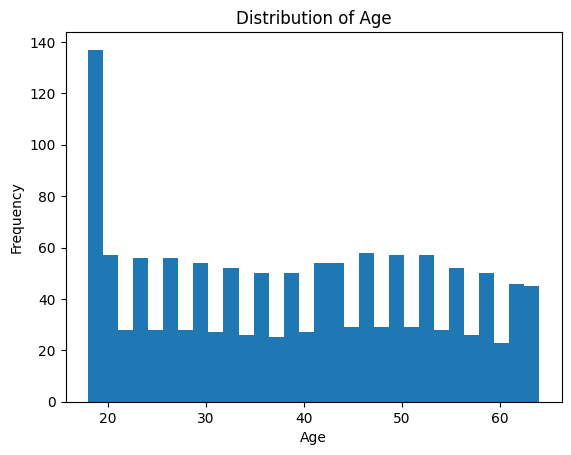

In [17]:
plt.figure()
plt.hist(df['age'], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()


Insights

Age ranges from 18 to 64 years

The distribution is almost uniform

Most policyholders are young to middle-aged adults

No extreme skewness observed

2) BMI Distribution

In [18]:
df['bmi'].describe()


,bmi
count,1338.000000
mean,30.663397
std,6.098187
min,15.960000
25%,26.296250
50%,30.400000
75%,34.693750
max,53.130000


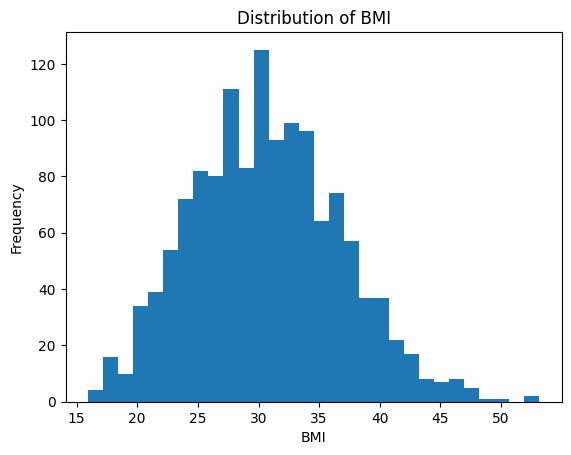

In [19]:
plt.figure()
plt.hist(df['bmi'], bins=30)
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.title("Distribution of BMI")
plt.show()


Insights

BMI values range approximately from 16 to 53

Majority of individuals have BMI between 20 and 35

Distribution is slightly right-skewed

Presence of higher BMI values indicates overweight and obese individuals

3) Children Distribution

In [20]:
df['children'].value_counts()


,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


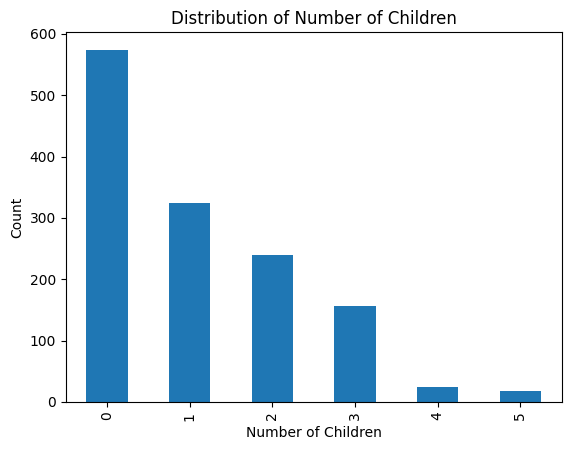

In [21]:
plt.figure()
df['children'].value_counts().plot(kind='bar')
plt.xlabel("Number of Children")
plt.ylabel("Count")
plt.title("Distribution of Number of Children")
plt.show()


Insights

Most policyholders have 0, 1, or 2 children

Very few individuals have more than 3 dependents

This feature is discrete numerical

Distribution is right-skewed

4) Charges Distribution

In [22]:
df['charges'].describe()


,charges
count,1338.000000
mean,13270.422265
std,12110.011237
min,1121.873900
25%,4740.287150
50%,9382.033000
75%,16639.912515
max,63770.428010


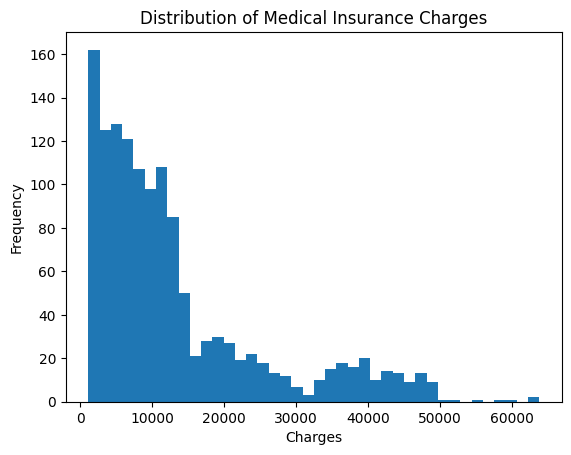

In [23]:
plt.figure()
plt.hist(df['charges'], bins=40)
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Medical Insurance Charges")
plt.show()


Insights

Charges range from very low to extremely high

Distribution is highly right-skewed

Most individuals have low to moderate insurance costs

Few high-cost claims significantly increase the mean

Indicates presence of outliers

4.2 Distribution of Categorical Features



*   sex

*   smoker
*   region





1) Sex Distribution

In [24]:
df['sex'].value_counts()


,count
sex,
male,676
female,662


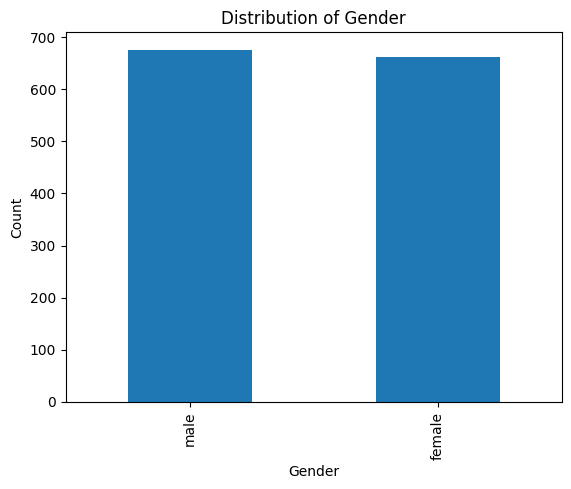

In [25]:
plt.figure()
df['sex'].value_counts().plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Distribution of Gender")
plt.show()


Insights

Almost equal number of male and female policyholders

Gender distribution is balanced

Indicates no gender bias in the dataset

2) Smoker Distribution

In [26]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


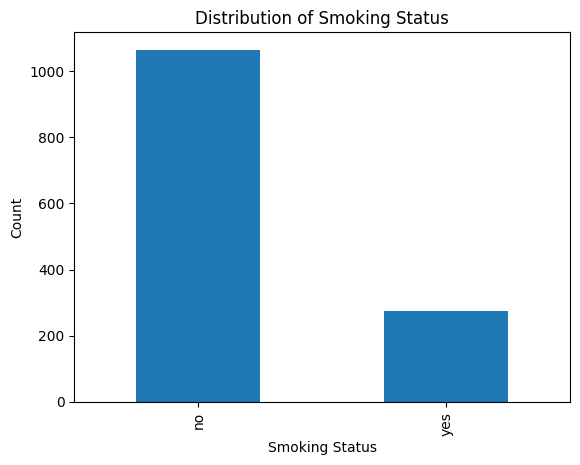

In [27]:
plt.figure()
df['smoker'].value_counts().plot(kind='bar')
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.title("Distribution of Smoking Status")
plt.show()


Insights

Majority of policyholders are non-smokers

Smokers represent a smaller proportion

This variable is expected to have a strong influence on insurance charges

3) Region Distribution


In [28]:
df['region'].value_counts()


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


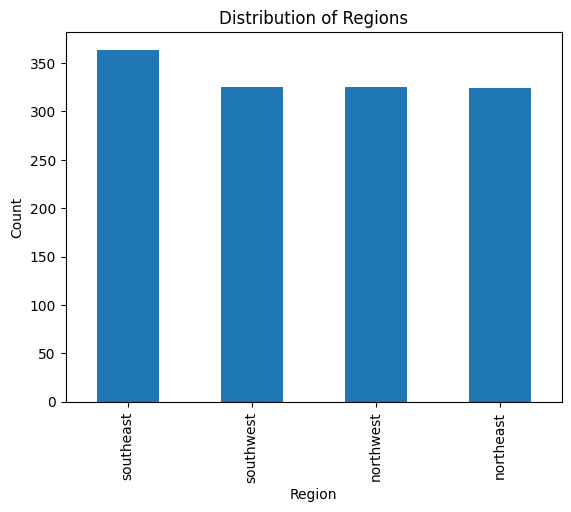

In [29]:
plt.figure()
df['region'].value_counts().plot(kind='bar')
plt.xlabel("Region")
plt.ylabel("Count")
plt.title("Distribution of Regions")
plt.show()


Insights

Policyholders are almost evenly distributed across all regions

No region dominates the dataset

Region alone may have less impact on insurance charges

## Outlier Detection (Univariate)

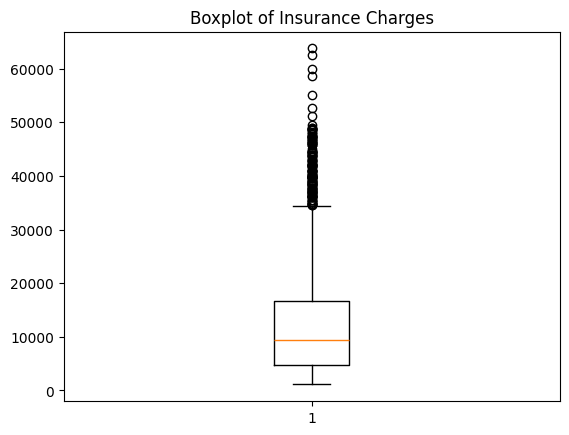

In [30]:
plt.figure()
plt.boxplot(df['charges'])
plt.title("Boxplot of Insurance Charges")
plt.show()


Insight

Significant outliers are present in insurance charges

These may represent high-risk individuals (smokers, high BMI, older age)

**Overall Univariate Analysis Summary :**

The dataset contains a healthy mix of numerical and categorical features

Most numerical variables show right-skewed distributions

The target variable (charges) contains outliers

Categorical variables are well-balanced

The dataset is suitable for machine learning modeling

**OUTLIER REMOVAL**

Outliers mainly affect:

charges (highly skewed)

bmi (few extreme values)

In [31]:
# Function to Remove Outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [32]:
# Remove Outliers from BMI and Charges
df_clean = df.copy()

df_clean = remove_outliers_iqr(df_clean, 'bmi')
df_clean = remove_outliers_iqr(df_clean, 'charges')

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original shape: (1338, 7)
After outlier removal: (1191, 7)


Outliers were removed using the IQR method to reduce skewness and improve model stability.

##BIVARIATE ANALYSIS

Bivariate analysis studies the relationship between two variables, especially features vs target (charges).

In [58]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [59]:
X_bmi = df[["bmi", "charges"]]

scaler = StandardScaler()
X_bmi_scaled = scaler.fit_transform(X_bmi)

kmeans_bmi = KMeans(n_clusters=3, random_state=42)
df["BMI_Cluster"] = kmeans_bmi.fit_predict(X_bmi_scaled)


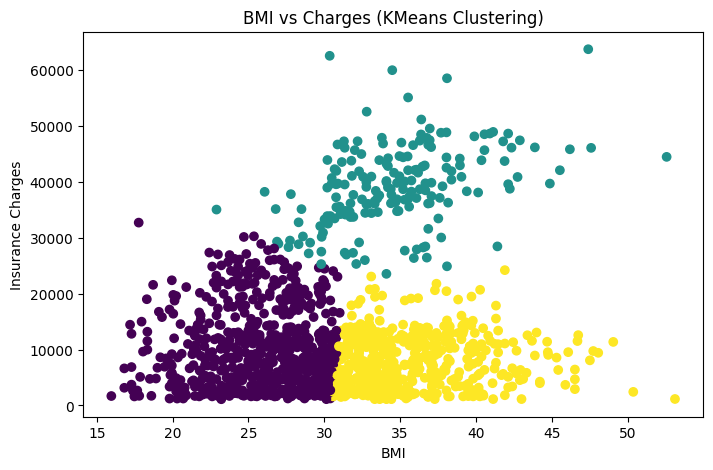

In [60]:
plt.figure(figsize=(8,5))
plt.scatter(df["bmi"], df["charges"], c=df["BMI_Cluster"])
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Charges (KMeans Clustering)")
plt.show()


Observations

The data is divided into three distinct clusters:

Low BMI – Low Charges

Moderate BMI – Medium Charges

High BMI – High Charges

Individuals with higher BMI tend to fall into higher insurance cost clusters.

The spread of charges increases significantly as BMI increases.

Interpretation

BMI is an indicator of health risk, but not the sole factor affecting insurance charges.

Even at similar BMI levels, different charge clusters exist, suggesting:

Influence of smoking

Age and other health conditions

In [61]:
# Age vs Charges — KMeans Clustering
X_age = df[["age", "charges"]]

X_age_scaled = scaler.fit_transform(X_age)

kmeans_age = KMeans(n_clusters=3, random_state=42)
df["Age_Cluster"] = kmeans_age.fit_predict(X_age_scaled)

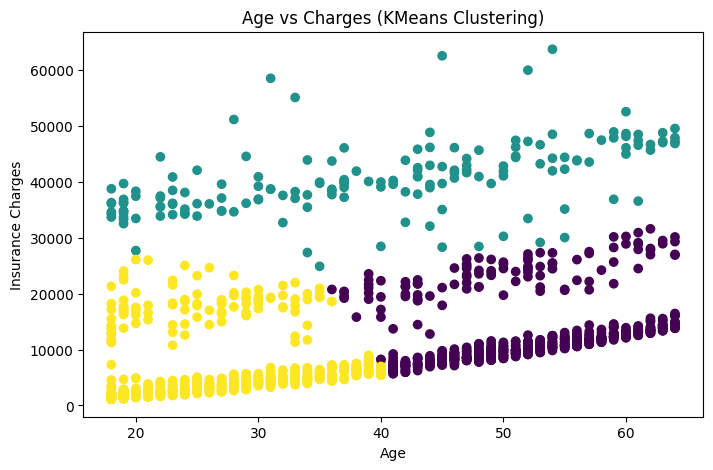

In [62]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["charges"], c=df["Age_Cluster"])
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Charges (KMeans Clustering)")
plt.show()


Observations

Clustering clearly separates individuals into:

Young age – Low charges

Middle age – Moderate charges

Older age – High charges

Insurance charges increase consistently with age.

Older individuals dominate the high-cost cluster.

Interpretation

Age shows a strong positive correlation with insurance charges.

The clusters indicate increasing medical risk and healthcare usage as age increases.

The band-like structure is explained by distinct cost groups, not random noise.

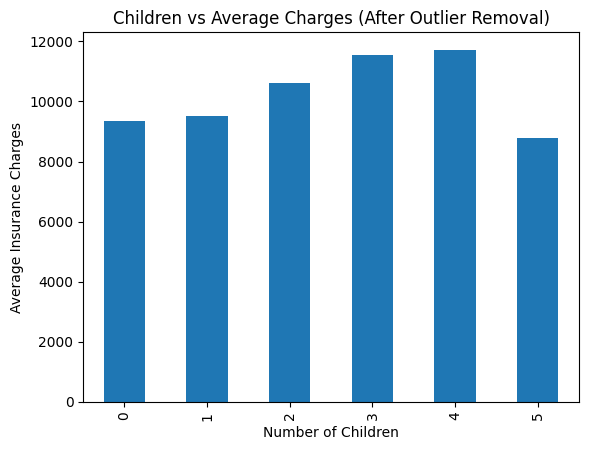

In [35]:
# Children vs Charges

plt.figure()
df_clean.groupby('children')['charges'].mean().plot(kind='bar')
plt.xlabel("Number of Children")
plt.ylabel("Average Insurance Charges")
plt.title("Children vs Average Charges (After Outlier Removal)")
plt.show()

Insights & Inference

Insurance charges increase slightly with number of children

Impact is weak compared to age and smoker status

Children count has low predictive power individually

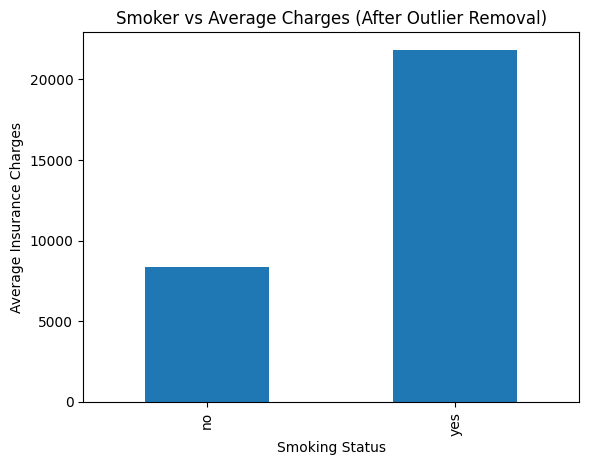

In [36]:
# Smoker vs Charges

plt.figure()
df_clean.groupby('smoker')['charges'].mean().plot(kind='bar')
plt.xlabel("Smoking Status")
plt.ylabel("Average Insurance Charges")
plt.title("Smoker vs Average Charges (After Outlier Removal)")
plt.show()

Insights & Inference

Smokers have significantly higher charges than non-smokers

Smoking is the strongest influencing factor

Even after removing outliers, difference remains very large

This variable is critical for model prediction

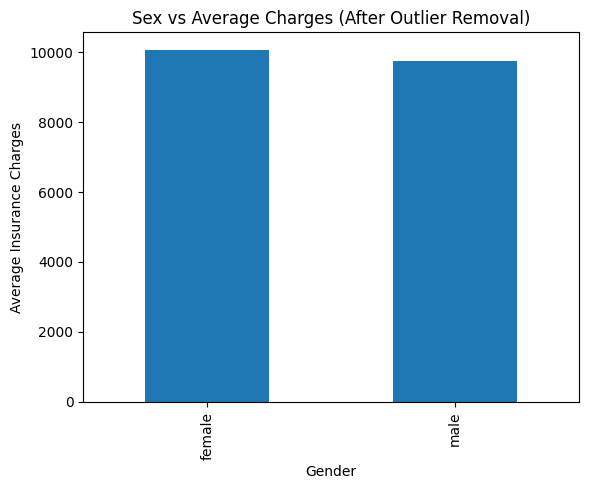

In [37]:
# Sex vs Charges

plt.figure()
df_clean.groupby('sex')['charges'].mean().plot(kind='bar')
plt.xlabel("Gender")
plt.ylabel("Average Insurance Charges")
plt.title("Sex vs Average Charges (After Outlier Removal)")
plt.show()

Insights & Inference

Average charges for males and females are almost similar

Gender has minimal impact on insurance cost

Sex alone is a weak predictor

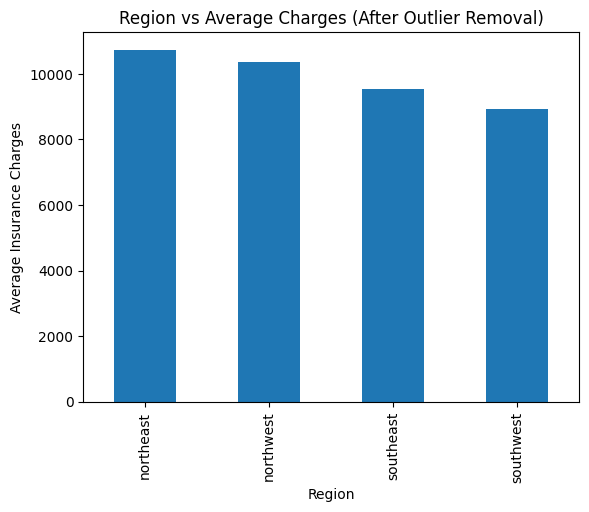

In [38]:
# Region vs Charges

plt.figure()
df_clean.groupby('region')['charges'].mean().plot(kind='bar')
plt.xlabel("Region")
plt.ylabel("Average Insurance Charges")
plt.title("Region vs Average Charges (After Outlier Removal)")
plt.show()

Insights & Inference

Minor variation in charges across regions

No region shows extreme dominance

Region has low influence on insurance charges

FINAL BIVARIATE CONCLUSION

After removing outliers, relationships between features and insurance charges became clearer.

Smoking status emerged as the most influential factor, followed by age and BMI.

Gender, region, and number of children showed minimal impact on insurance cost.

## MULTI-VARIATE ANALYSIS

Multivariate analysis helps understand the combined effect of multiple features on the target variable (charges).

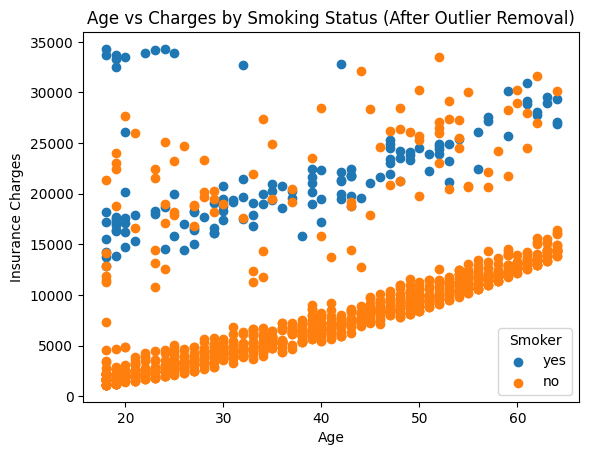

In [39]:
# Age vs Charges vs Smoker

plt.figure()

for status in df_clean['smoker'].unique():
    subset = df_clean[df_clean['smoker'] == status]
    plt.scatter(subset['age'], subset['charges'], label=status)

plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Charges by Smoking Status (After Outlier Removal)")
plt.legend(title="Smoker")
plt.show()

Insights & Inference

Smokers have much higher charges across all age groups

For non-smokers, charges increase gradually with age

Smoking amplifies the impact of age on medical cost

Confirms interaction effect between age and smoking

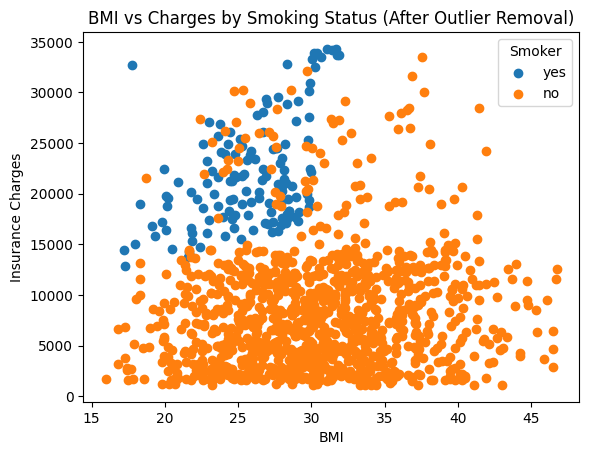

In [40]:
# BMI vs Charges vs Smoker

plt.figure()

for status in df_clean['smoker'].unique():
    subset = df_clean[df_clean['smoker'] == status]
    plt.scatter(subset['bmi'], subset['charges'], label=status)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Charges by Smoking Status (After Outlier Removal)")
plt.legend(title="Smoker")
plt.show()

Insights & Inference

Smokers with high BMI incur extremely high charges

For non-smokers, BMI impact is moderate

Smoking and BMI together create a high-risk group

Strong justification for non-linear models

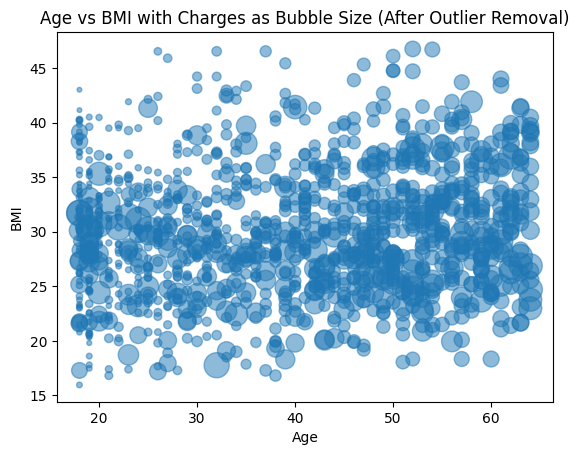

In [41]:
# Age vs BMI vs Charges (Bubble Chart)

plt.figure()

plt.scatter(
    df_clean['age'],
    df_clean['bmi'],
    s=df_clean['charges'] / 100,  # bubble size
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Age vs BMI with Charges as Bubble Size (After Outlier Removal)")
plt.show()

Insights & Inference

Larger bubbles indicate higher insurance charges

Older individuals with higher BMI tend to have larger costs

Visualizes combined influence of age and BMI

<Figure size 640x480 with 0 Axes>

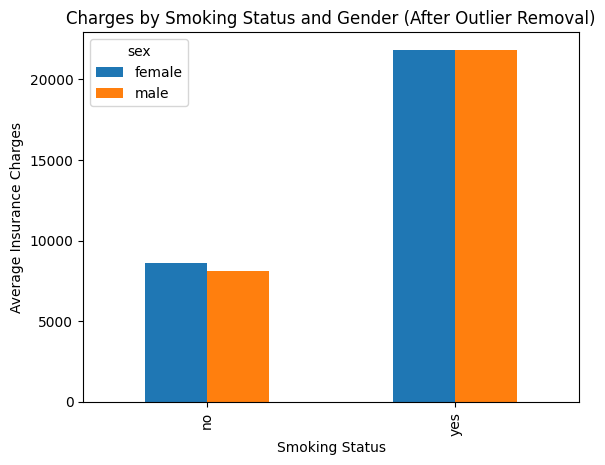

In [42]:
# Charges by Smoker and Sex

grouped = df_clean.groupby(['smoker', 'sex'])['charges'].mean()

plt.figure()
grouped.unstack().plot(kind='bar')
plt.xlabel("Smoking Status")
plt.ylabel("Average Insurance Charges")
plt.title("Charges by Smoking Status and Gender (After Outlier Removal)")
plt.show()

Insights & Inference

Smoking status dominates cost differences across genders

Male and female smokers have similarly high charges

Gender impact is negligible when compared to smoking

<Figure size 640x480 with 0 Axes>

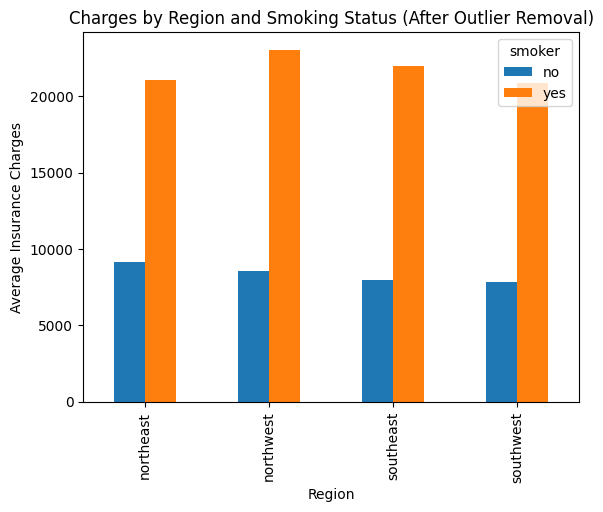

In [43]:
# Charges by Region and Smoker

grouped = df_clean.groupby(['region', 'smoker'])['charges'].mean()

plt.figure()
grouped.unstack().plot(kind='bar')
plt.xlabel("Region")
plt.ylabel("Average Insurance Charges")
plt.title("Charges by Region and Smoking Status (After Outlier Removal)")
plt.show()

Insights & Inference

Smokers have higher charges in all regions

Regional differences are minor

Smoking impact is consistent geographically

## PAIR PLOT

A pair plot helps visualize:

Pairwise relationships

Distribution of each numerical variable

Overall interaction patterns

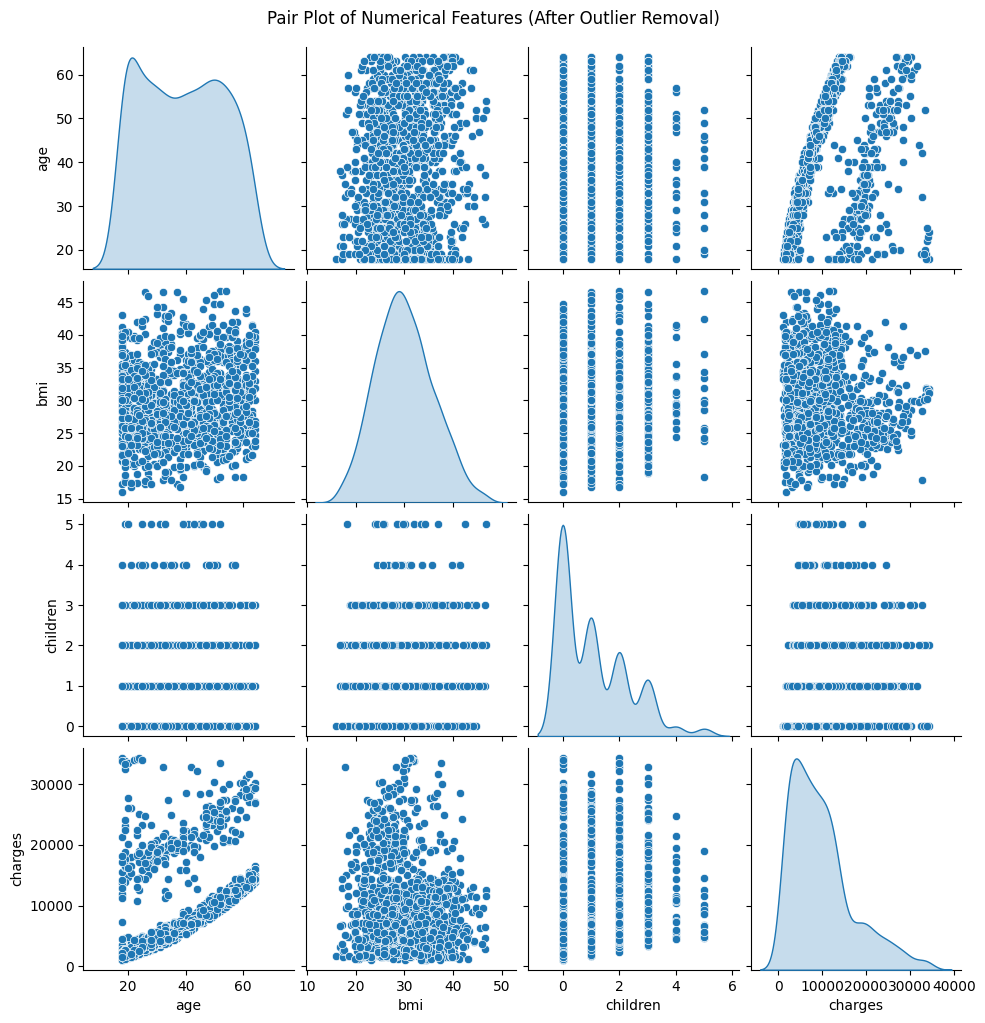

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df_clean[['age', 'bmi', 'children', 'charges']],
    diag_kind='kde'
)

plt.suptitle("Pair Plot of Numerical Features (After Outlier Removal)", y=1.02)
plt.show()


**Insights & Inference from Pair Plot**

 1) Age vs Charges

Clear positive linear trend

Charges increase with age

Pattern becomes cleaner after outlier removal

2) BMI vs Charges

Mild to moderate positive relationship

Higher BMI values often associate with higher charges

Relationship is not perfectly linear

3) Children vs Charges

Weak relationship

Charges do not increase significantly with children count

Indicates low predictive strength

4) Age vs BMI

No strong correlation

Age and BMI are largely independent



**OVERALL SUMMARY :**

The pair plot analysis after outlier removal shows clear relationships between age, BMI, and insurance charges.

Age exhibits the strongest linear association with charges, while BMI shows a moderate influence.

Number of children has minimal effect on insurance cost.

Overall, the cleaned dataset displays well-defined patterns suitable for regression modeling.

#Skewness BEFORE Outlier Removal

In [45]:
# Skewness before outlier removal
skew_before = df[['age', 'bmi', 'children', 'charges']].skew()

print("Skewness Before Outlier Removal:")
print(skew_before)

Skewness Before Outlier Removal:
age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64


## Skewness AFTER Outlier Removal

In [46]:
# Skewness after outlier removal
skew_after = df_clean[['age', 'bmi', 'children', 'charges']].skew()

print("\nSkewness After Outlier Removal:")
print(skew_after)


Skewness After Outlier Removal:
age         0.068210
bmi         0.265082
children    0.982898
charges     1.159964
dtype: float64


## Skewness Comparison Table

In [47]:
skew_comparison = skew_before.to_frame(name='Before_Outlier_Removal')
skew_comparison['After_Outlier_Removal'] = skew_after

print("\nSkewness Comparison:")
print(skew_comparison)



Skewness Comparison:
          Before_Outlier_Removal  After_Outlier_Removal
age                     0.055673               0.068210
bmi                     0.284047               0.265082
children                0.938380               0.982898
charges                 1.515880               1.159964


## Before Outlier Removal

Charges showed very high positive skewness, indicating extreme right-skewed distribution

BMI had moderate positive skewness due to a few extreme values

Age showed near-symmetric distribution

Children was right-skewed as it is a discrete count variable

## After Outlier Removal

Skewness of charges reduced significantly, making distribution more balanced

BMI skewness decreased, indicating removal of extreme BMI values

Age skewness remained almost unchanged, as it had no extreme outliers

Children skewness remained, which is expected for discrete features

##HISTOGRAM  and KDE PLOTS

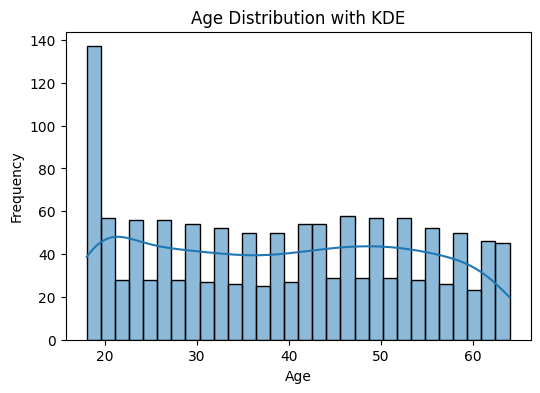

In [48]:
# Histogram + KDE for Age
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True, bins=30)
plt.title("Age Distribution with KDE")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The histogram shows a fairly uniform distribution across age groups.

Most individuals lie between 20 to 60 years.

No extreme outliers are observed.

Age is evenly spread and can act as a stable predictor of insurance charges.

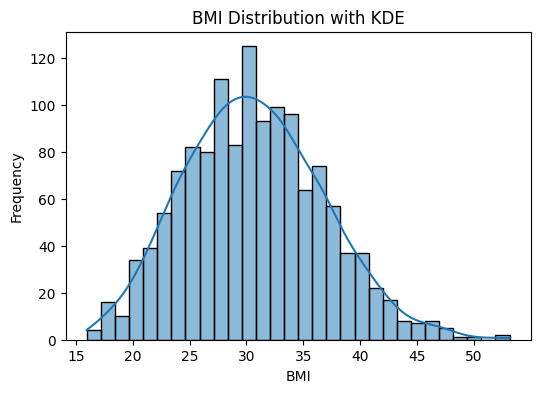

In [49]:
# Histogram + KDE for BMI
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], kde=True, bins=30)
plt.title("BMI Distribution with KDE")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

The BMI histogram is right-skewed.

A large portion of individuals fall in the overweight and obese categories.

Higher BMI values appear less frequently but exist as outliers.

Higher BMI is associated with increased health risk and higher insurance charges.

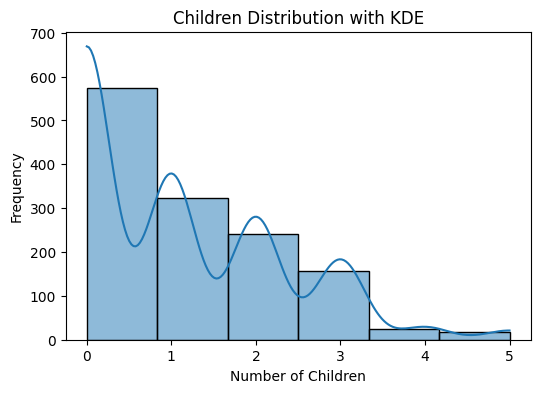

In [50]:
# Histogram + KDE for Children
plt.figure(figsize=(6,4))
sns.histplot(df['children'], kde=True, bins=6)
plt.title("Children Distribution with KDE")
plt.xlabel("Number of Children")
plt.ylabel("Frequency")
plt.show()

The histogram shows a discrete distribution.

Most policyholders have 0 to 2 children.

Very few individuals have more than 3 children.

Number of children has a limited range and a moderate influence on insurance cost.

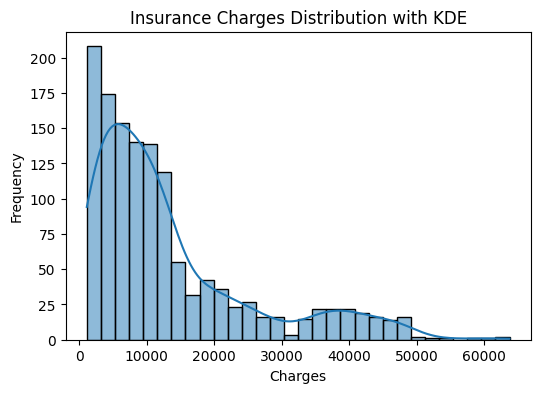

In [51]:
# Histogram + KDE for Insurance Charges
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], kde=True, bins=30)
plt.title("Insurance Charges Distribution with KDE")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

The histogram is highly right-skewed.

Majority of individuals have low to moderate charges.

A small group shows very high medical expenses.

Presence of extreme values indicates outliers and justifies using robust ML models.

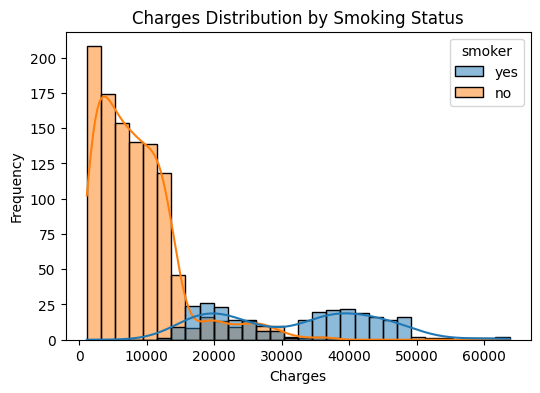

In [52]:
# Histogram + KDE by Smoking Status (Charges)
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='charges', hue='smoker', kde=True, bins=30)
plt.title("Charges Distribution by Smoking Status")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

Smokers have significantly higher charges

Distribution clearly separates smokers vs non-smokers

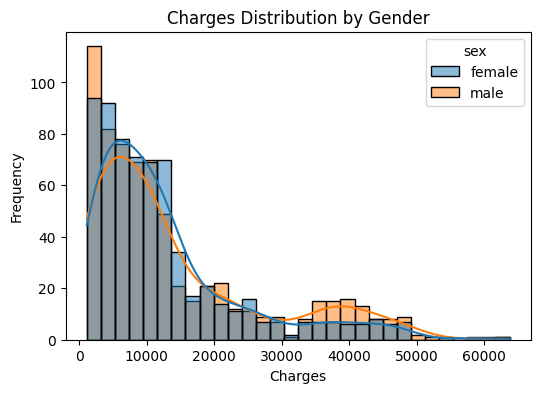

In [53]:
# Histogram + KDE by Gender (Charges)
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='charges', hue='sex', kde=True, bins=30)
plt.title("Charges Distribution by Gender")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

Male and female charge distributions are similar

Gender impact is minimal

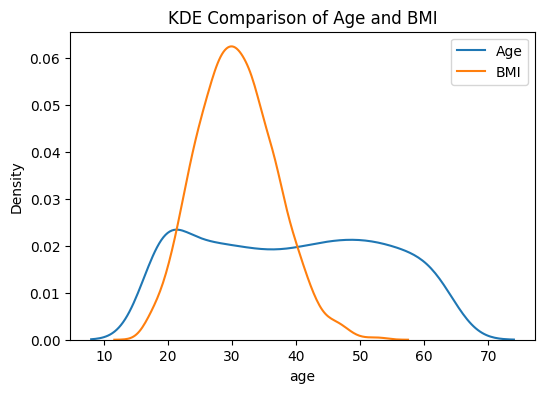

In [54]:
# KDE Plot (Only) – Combined View
plt.figure(figsize=(6,4))
sns.kdeplot(df['age'], label='Age')
sns.kdeplot(df['bmi'], label='BMI')
plt.title("KDE Comparison of Age and BMI")
plt.legend()
plt.show()

Shows smooth probability distribution

Useful for comparing feature spread

**Final Visualization Summary :**

Histograms show distribution shape

KDE plots reveal density & skewness

Charges and BMI are right-skewed

Smoking creates distinct cost patterns

Confirms need for robust ML models

##Correlation Matrix

In [55]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

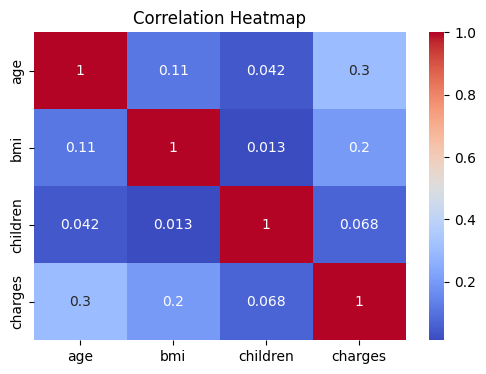

In [56]:
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insight
*  age, bmi positively correlated with charges
*   Confirms suitability for regression models
*   children has weak correlation




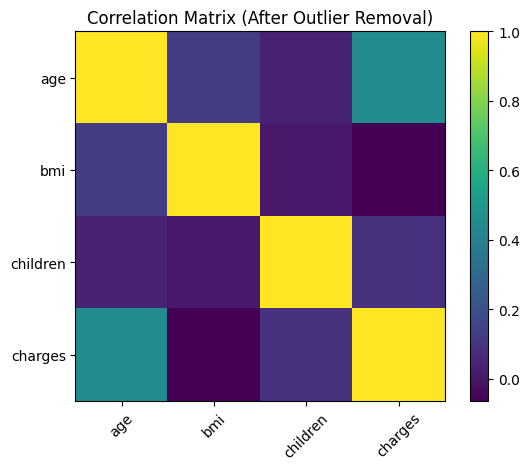

In [57]:
# Correlation Heatmap (After Outlier Removal)

plt.figure()
corr = df_clean.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix (After Outlier Removal)")
plt.show()

##Conclusion



*   Dataset is clean with no missing values




*   Insurance charges are highly skewed



*   Smoking, BMI, and age are key cost drivers




Descriptive statistics show that most policyholders are middle-aged adults with an average BMI in the overweight to obese range, which has a noticeable impact on medical insurance charges.

The target variable, insurance charges, exhibits a right-skewed distribution with significant outliers, indicating that a small group of individuals incurs extremely high medical costs.

Visualization-based analysis highlights that smoking status is the most influential factor affecting insurance charges, followed by BMI and age.

Smokers, particularly those with higher BMI, tend to have substantially higher medical expenses compared to non-smokers.

Variables such as gender, number of children, and region show relatively minor influence on insurance costs